<a href="https://colab.research.google.com/github/CoF-Stats/CoFAI-d2l-reading-group-2026/blob/main/notebooks/week01_regression_notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 01 Notes

## Technical

- Installing `d2l` requires `--no-deps` flag, so it should look like `!pip install d2l --no-deps`.

- Contributing to Colab notebooks requires Cmd + Enter

- `numpy` uses `NaN`, Python in general uses `'None'` or `nan` for floats.





## Preliminaries reading

- Tensors: Multi-dimensional arrays

  - Cannot be ragged

  - *How do we deal with missing data?*

  -



## Questions on Chapter 3

- What's up with this loss function?

----
**Analytic solution to the least squares estimation problem in more detail**

Starting with $y_1, y_2, ..., y_n$ as our sample of outputs and $\mathbf{x}_1, \mathbf{x}_2, ..., \mathbf{x}_n$ as the collection of vectors, each with $d$ measurments of $d$ *features*, we collect all the $y$'s into a vector of length $n$ and stack the $\mathbf{x}'s$ in the rows of a matrix $\underset{n \times d}{\mathbf{X}}$. The sum of squared errors can be rewritten as

$$
\begin{aligned}
SSE &= (\mathbf{y} - \mathbf{Xw})^\top (\mathbf{y} - \mathbf{Xw})\\
&= \mathbf{y}^\top\mathbf{y} - 2\mathbf{y}^\top \mathbf{Xw} + \mathbf{w}^\top\mathbf{X}^\top \mathbf{Xw}.
\end{aligned}
$$

Then, the partial derivative with respect to $\mathbf{w}$ is

$$
\begin{aligned}
\frac{\partial}{\partial \mathbf{w}} &\mathbf{y}^\top\mathbf{y} - 2\mathbf{y}^\top \mathbf{Xw} + \mathbf{w}^\top\mathbf{X}^\top \mathbf{Xw}\\
&= -2\mathbf{X}^\top \mathbf{y} + 2 \mathbf{X}^\top \mathbf{Xw}\\
\end{aligned}
$$

Setting to 0 and solving for $\mathbf{w}$ gives

$$
\begin{aligned}
0 &= -2\mathbf{X}^\top \mathbf{y} + 2 \mathbf{X}^\top \mathbf{X\hat{w}}\\
2\mathbf{X}^\top \mathbf{y} &= 2 \mathbf{X}^\top \mathbf{X\hat w}\\
\frac{1}{2}(\mathbf{X}^\top \mathbf{X})^{-1}2\mathbf{X}^\top \mathbf{y} &= \frac{1}{2}(\mathbf{X}^\top \mathbf{X})^{-1} 2 \mathbf{X}^\top \mathbf{X\hat w}\\
(\mathbf{X}^\top \mathbf{X})^{-1}\mathbf{X}^\top \mathbf{y} &= \mathbf{\hat w}
\end{aligned}
$$

----

- Minibatch optimization:

  - Are we resampling with replacement for each minibatch?

  - Or, are we splitting the dataset?

  - **It sounds like, for a given epoch, we permute the rows of data (examples), then partition into $N / | B |$ batches**.


## Exercises

### 3.1.6.3 Polynomial as a neural net

#### Dusty's attempt

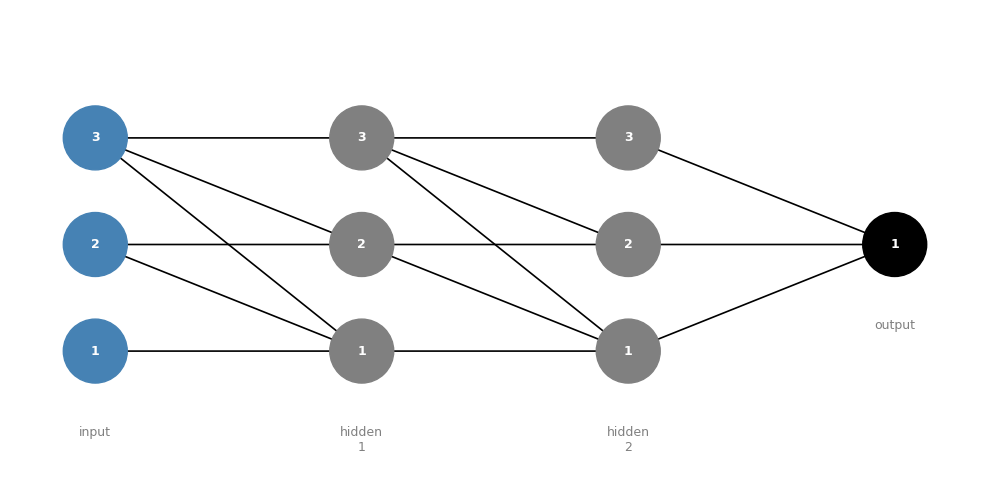

In [1]:

# Some code to make a diagram
# lots of help from Claude for the figure code
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def draw_custom_network():
    fig, ax = plt.subplots(figsize=(10, 6))

    # Layer x-positions and node counts
    layers = {
        'input':   (0,   3),
        'hidden1': (2.5, 3),
        'hidden2': (5,   3),
        'output':  (7.5, 1),
      }

    # Build node positions: centered vertically
    def node_positions(x, n):
        return [(x, j - (n - 1) / 2) for j in range(n)]

    pos = {name: node_positions(x, n) for name, (x, n) in layers.items()}

    # Draw edges BEFORE nodes so nodes render on top
    # Input -> Hidden1: lower triangular (i -> j if j <= i)
    for i, (x1, y1) in enumerate(pos['input']):
        for j, (x2, y2) in enumerate(pos['hidden1']):
            if j <= i:
                ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                            arrowprops=dict(arrowstyle="-|>", lw=1.2))

    # Hidden1 -> Hidden2: i -> j only if j <= i (0-indexed)
    for i, (x1, y1) in enumerate(pos['hidden1']):
        for j, (x2, y2) in enumerate(pos['hidden2']):
            if j <= i:
                ax.annotate(
                    "", xy=(x2, y2),
                    xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="-|>", lw=1.2)
                )

    # Hidden2 -> Output: all 3 -> 1
    for x1, y1 in pos['hidden2']:
        x2, y2 = pos['output'][0]
        ax.annotate(
            "", xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops=dict(arrowstyle="-|>", lw=1.2)
        )

    # Draw nodes
    node_style = dict(radius=0.3, zorder=4)
    colors = {'input': 'steelblue', 'hidden1': 'grey',
              'hidden2': 'grey', 'output': 'black'}

    for name, positions in pos.items():
        for idx, (x, y) in enumerate(positions):
            circle = plt.Circle((x, y), color=colors[name], **node_style)
            ax.add_patch(circle)
            ax.text(x, y, str(idx + 1), ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold', zorder=5)

    # Layer labels
    for name, (x, n) in layers.items():
        bottom_y = -(n - 1) / 2 - 0.7
        ax.text(x, bottom_y, name.replace(
            'hidden', 'hidden\n').replace('output', 'output'),
                  ha='center', va='top', fontsize=9, color='gray'
        )

    ax.set_xlim(-0.8, 8.3)
    ax.set_ylim(-2.2, 2.2)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('network_diagram.png', dpi=150, bbox_inches='tight')
    plt.show()

draw_custom_network()

With this structure, let $\bf x$ denote the input vector, and ${\bf W}^{(l)}$ denote the weights matrix of layer $l$, starting with 0 as the matrix defining the edges connecting the input to the first hidden layer, and ${\bf h}^{(l)}$ denote the nodes of the $l^\text{th}$ hidden layer. With this structure, define the following:

$$
{\bf W}^{(0)} := \begin{bmatrix}
w_{11}^{(0)} & 0 & 0\\
w_{21}^{(0)} & w_{22}^{(0)} & 0\\
w_{31}^{(0)} & w_{32}^{(0)} & w_{33}^{(0)}
\end{bmatrix}\ \text{(unknown weights)}
$$

$$
{\bf W}^{(1)} := \begin{bmatrix}
x_1 & 0 & 0\\
x_2 & x_2 & 0\\
x_3 & x_3 & x_3
\end{bmatrix} \ \text{(known weights)}
$$

$$
{\bf w}^{(2)} := \begin{bmatrix}
w_1^{(2)} = 1\\
w_2^{(2)} = 1\\
w_3^{(2)} = 1
\end{bmatrix}\ \text{(known weights)}
$$

and let ${\bf b}^{(1)} = {\bf 0}$.

Substituting these in for the network equations, we get

$$
{\bf h}^{(1)} = {\bf W}^{(0)} {\bf x}  + {\bf b}^{(0)}= \begin{bmatrix}
w_{11}^{(0)}x_1 + b_1^{(0)}\\
w_{21}^{(0)} x_1 + w_{22}^{(0)}x_2 + b_2^{(0)}\\
w_{31}^{(0)} x_1 + w_{32}^{(0)}x_2 + w_{33}^{(0)}x_3 + b_3^{(0)}\\
\end{bmatrix}
$$

$$
{\bf h}^{(2)} = {\bf W}^{(1)} {\bf h}^{(1)} + {\bf b}^{(1)} = \begin{bmatrix}
x_1 h_1^{(1)} \\
x_1 h_2^{(1)} + x_2 h_2^{(1)} \\
x_1 h_3^{(1)} + x_2 h_3^{(1)} + x_3 h_3^{(1)}
\end{bmatrix}
$$

and

$$
o = ({\bf w}^{(2)})^\top {\bf h}^{(2)} + {\bf b}^{(2)} = b^{(2)} + \sum_{i = 1}^3 h_i^{(2)}
$$

Now, expanding for example $h_2^{(2)}$, in the output layer, we get

$$
\begin{aligned}
h_2^{(2)} &= x_1 \big( w_{21}^{(0)} x_1 + w_{22}^{(0)}x_2 + b_2^{(0)} \big) + x_2 \big( w_{21}^{(0)} x_1 + w_{22}^{(0)}x_2 + b_2^{(0)} \big)\\
&= w'_{12} x_1 x_2 + w'_{22}x_2x_2 + w_1' x_1 + w_{2}' x_2
\end{aligned}
$$

where we have *reparameterized* after collecting the like terms such that, for example, $w_{12}' = (w_{21}^{(0)} + w_{22}^{(0)})$. Repeating the process of expanding each of the component of the sum for the output layer and then collecting like terms yields the polynomial equation:

$$
o = b + \sum_i w'_i x_i + \sum_{j \le i} w_{ij}' x_i x_j
$$

### Exercise 3.1.6.6: Why deep linear networks don't work

#### Dusty's attempt

Suppose we tried this with the following setup:

$$
\begin{aligned}
{\bf h}^{(1)} &= {\bf W}^{(0)} {\bf x} + {\bf b}^{(0)}\\
%
{\bf o} &= {\bf W}^{(1)} {\bf h}^{(1)} + {\bf b}^{(1)}
\end{aligned}
$$

Expanding the expression for the output layer,

$$
\begin{aligned}
{\bf o} = {\bf W}^{(1)} {\bf h}^{(1)} + {\bf b}^{(1)} &= {\bf W}^{(1)} \big( {\bf W}^{(0)} {\bf x} + {\bf b}^{(0)}\big) + {\bf b}^{(1)}\\
&= {\bf W}^{(1)}{\bf W}^{(0)} {\bf x} + {\bf W}^{(1)}{\bf b}^{(0)} + {\bf b}^{(1)}\\
&= {\bf W}' {\bf x} + {\bf b}'
\end{aligned}
$$
we see that we didn't gain anything by adding an additional layer to the network; it is still just a linear model.

